# Notebook 05 – Random Forest

## Objectif

Après avoir étudié la Régression Logistique et le Decision Tree, ce notebook a pour objectif d'entraîner un modèle Random Forest afin d'améliorer la prédiction des contrats présentant un risque de sinistre.

Le Random Forest combine plusieurs arbres de décision et prend une décision finale par vote majoritaire, ce qui permet généralement d'obtenir un modèle plus robuste et plus stable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

pd.set_option("display.max_columns", None)

In [2]:
data = pd.read_csv("../data/processed/insurance_clean.csv")

In [3]:
print(data.shape)
data.head()

(678013, 14)


,IDpol,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Area,Density,Region,ClaimAmountTotal,HasClaim
0,1,1,0.10,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,1
1,3,1,0.77,5,0,55,50,B12,Regular,D,1217,Rhone-Alpes,0.0,1
2,5,1,0.75,6,2,52,50,B12,Diesel,B,54,Picardie,0.0,1
3,10,1,0.09,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,1
4,11,1,0.84,7,0,46,50,B12,Diesel,B,76,Aquitaine,0.0,1


In [4]:
features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "VehBrand",
    "VehGas",
    "Area",
    "Density",
    "Region"
]

X = data[features]
y = data["HasClaim"]

In [5]:
print("X :", X.shape)
print("y :", y.shape)

X : (678013, 10)
y : (678013,)


In [6]:
numeric_features = [
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

categorical_features = [
    "VehBrand",
    "VehGas",
    "Area",
    "Region"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
print(X_train.shape)
print(X_test.shape)

(542410, 10)
(135603, 10)


Construire le premier Random Forest (Baseline)

In [9]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [10]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [11]:
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [12]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 4))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf)

print("\nMatrice de confusion :")
print(cm)

roc = roc_auc_score(y_test, y_proba_rf)

print("\nROC-AUC :", round(roc, 4))

Accuracy : 0.9477

Classification Report :
              precision    recall  f1-score   support

           0       0.95      1.00      0.97    128791
           1       0.26      0.02      0.04      6812

    accuracy                           0.95    135603
   macro avg       0.60      0.51      0.51    135603
weighted avg       0.92      0.95      0.93    135603


Matrice de confusion :
[[128361    430]
 [  6664    148]]

ROC-AUC : 0.6634


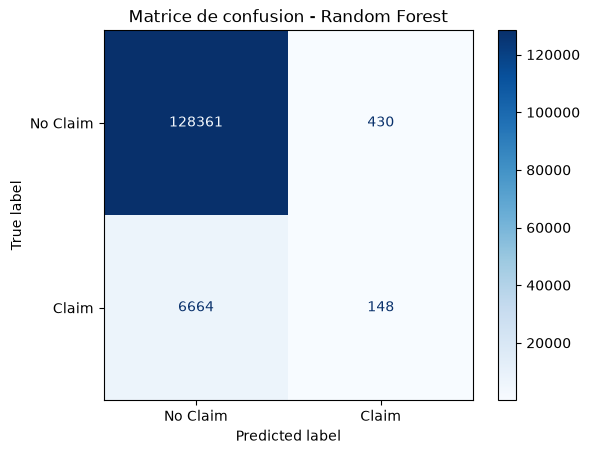

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No Claim", "Claim"])

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest")
plt.show()

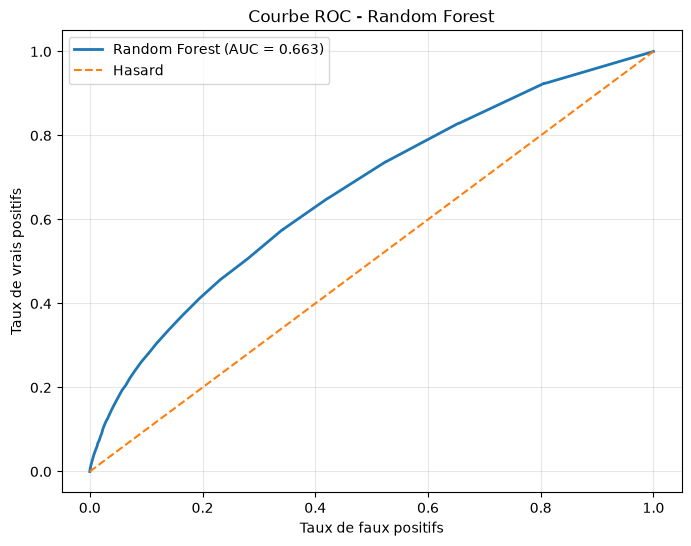

In [14]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2, label=f"Random Forest (AUC = {roc:.3f})")
plt.plot([0,1],[0,1],"--", label="Hasard")

plt.title("Courbe ROC - Random Forest")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Un premier modèle Random Forest composé de 100 arbres a été entraîné afin de comparer ses performances avec celles des modèles précédents. L'entraînement a nécessité environ 45 minutes, ce qui illustre le coût computationnel d'une forêt aléatoire sur un jeu de données de plus de 678 000 contrats. Les résultats montrent une accuracy de 94,77 % et un ROC-AUC de 0,663, indiquant une bonne capacité générale de discrimination. Toutefois, le rappel de la classe des contrats sinistrés reste limité à 2 %, ce qui montre que le modèle demeure fortement influencé par le déséquilibre des classes.

Créer le Random Forest équilibré

Ajoute une nouvelle cellule avec ce code :

In [15]:
rf_balanced_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [16]:
rf_balanced_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Exposure','VehPower','VehAge',...,'Area','Density','Region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatw

In [17]:
y_pred_rf_balanced = rf_balanced_pipeline.predict(X_test)
y_proba_rf_balanced = rf_balanced_pipeline.predict_proba(X_test)[:, 1]

In [18]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf_balanced), 4))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_rf_balanced))

cm_balanced = confusion_matrix(y_test, y_pred_rf_balanced)

print("\nMatrice de confusion :")
print(cm_balanced)

roc_balanced = roc_auc_score(y_test, y_proba_rf_balanced)

print("\nROC-AUC :", round(roc_balanced, 4))

Accuracy : 0.6297

Classification Report :
              precision    recall  f1-score   support

           0       0.97      0.63      0.76    128791
           1       0.08      0.65      0.15      6812

    accuracy                           0.63    135603
   macro avg       0.53      0.64      0.46    135603
weighted avg       0.93      0.63      0.73    135603


Matrice de confusion :
[[80964 47827]
 [ 2390  4422]]

ROC-AUC : 0.6986


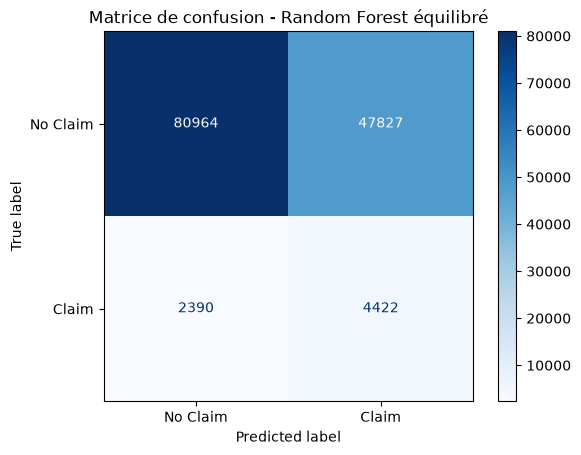

In [19]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["No Claim", "Claim"]
)

disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Random Forest équilibré")
plt.show()

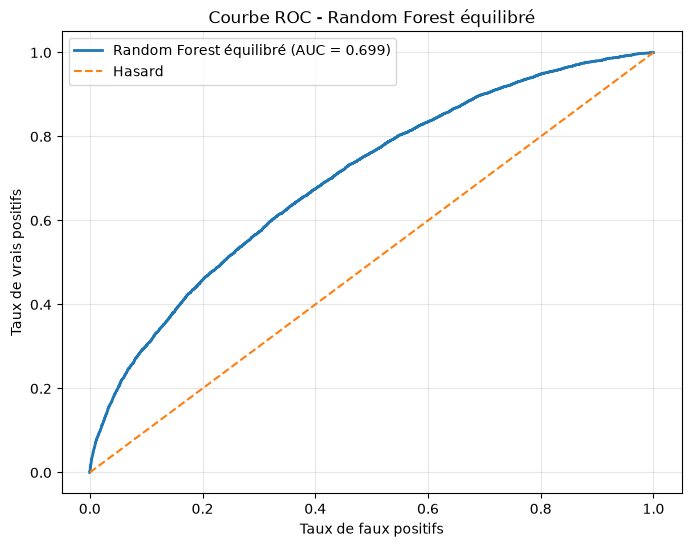

In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_rf_balanced)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, linewidth=2,
         label=f"Random Forest équilibré (AUC = {roc_balanced:.3f})")
plt.plot([0,1], [0,1], "--", label="Hasard")

plt.title("Courbe ROC - Random Forest équilibré")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

L'utilisation de class_weight="balanced" dans le Random Forest améliore considérablement la détection des contrats sinistrés. Le modèle obtient un rappel de 64,9 %, contre seulement 2 % pour la version classique, tout en atteignant le meilleur score ROC-AUC (0,6986) de tous les modèles étudiés. Bien que l'Accuracy diminue à 62,97 %, cette baisse est principalement due à une augmentation des faux positifs. Dans un contexte d'assurance automobile, cette approche est pertinente, car elle permet d'identifier une proportion beaucoup plus importante de contrats réellement risqués.

In [21]:
# Importance des variables
importances = rf_balanced_pipeline.named_steps["model"].feature_importances_

feature_names = rf_balanced_pipeline.named_steps["preprocessor"].get_feature_names_out()

importance_df = (
    pd.DataFrame({
        "Variable": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(10)

,Variable,Importance
40,remainder__Exposure,0.322271
42,remainder__VehAge,0.176740
44,remainder__BonusMalus,0.143647
43,remainder__DrivAge,0.078536
3,cat__VehBrand_B12,0.047166
45,remainder__Density,0.043642
41,remainder__VehPower,0.037272
11,cat__VehGas_Diesel,0.026627
12,cat__VehGas_Regular,0.017173
25,cat__Region_Centre,0.010123


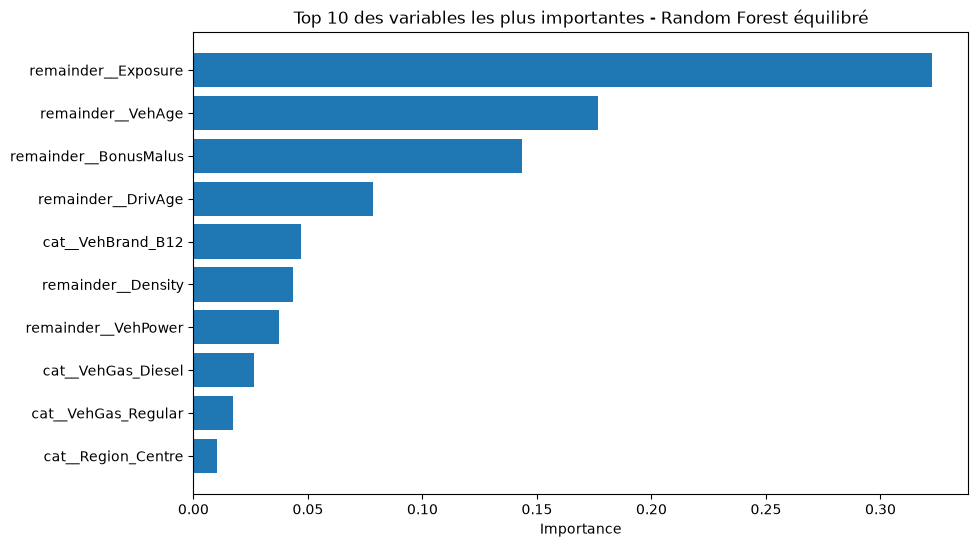

In [22]:
plt.figure(figsize=(10,6))

top10 = importance_df.head(10)

plt.barh(top10["Variable"][::-1], top10["Importance"][::-1])

plt.title("Top 10 des variables les plus importantes - Random Forest équilibré")
plt.xlabel("Importance")

plt.show()

L'analyse des importances des variables montre que l'exposition du contrat est le facteur le plus influent dans les décisions du Random Forest, suivie par l'âge du véhicule, le Bonus-Malus et l'âge du conducteur. Ces résultats sont cohérents avec les pratiques du secteur de l'assurance automobile, où la durée d'assurance, l'historique du conducteur et les caractéristiques du véhicule influencent directement le niveau de risque.

on passe à l'étape la plus professionnelle : l'optimisation automatique

In [23]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
param_dist = {
    "model__n_estimators": [50, 75, 100],
    "model__max_depth": [8, 10, 12, 15],
    "model__min_samples_leaf": [5, 10, 20],
    "model__min_samples_split": [10, 20, 50],
    "model__max_features": ["sqrt", "log2"]
}

In [25]:
random_search = RandomizedSearchCV(
    estimator=rf_balanced_pipeline,
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [8, 10, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [5, 10, ...], 'model__min_samples_split': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",6
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` c

In [26]:
print("Meilleurs paramètres :")
print(random_search.best_params_)

print("\nMeilleur ROC-AUC (validation croisée) :")
print(round(random_search.best_score_, 4))

Meilleurs paramètres :
{'model__n_estimators': 50, 'model__min_samples_split': 50, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 15}

Meilleur ROC-AUC (validation croisée) :
0.6938


In [27]:
best_model = random_search.best_estimator_

In [28]:
y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_best), 4))

print("\nClassification Report :")
print(classification_report(y_test, y_pred_best))

cm_best = confusion_matrix(y_test, y_pred_best)

print("\nMatrice de confusion :")
print(cm_best)

roc_best = roc_auc_score(y_test, y_proba_best)

print("\nROC-AUC :", round(roc_best, 4))

Accuracy : 0.6644

Classification Report :
              precision    recall  f1-score   support

           0       0.97      0.67      0.79    128791
           1       0.09      0.62      0.16      6812

    accuracy                           0.66    135603
   macro avg       0.53      0.64      0.47    135603
weighted avg       0.93      0.66      0.76    135603


Matrice de confusion :
[[85894 42897]
 [ 2608  4204]]

ROC-AUC : 0.7012


Afin d'améliorer les performances du Random Forest, une optimisation des hyperparamètres a été réalisée à l'aide de RandomizedSearchCV avec une validation croisée (cv=3). Les meilleurs paramètres obtenus sont n_estimators=50, max_depth=15, min_samples_leaf=10, min_samples_split=50 et max_features='sqrt'. Le modèle optimisé atteint une Accuracy de 66,44 %, un rappel de 61,7 % pour les contrats sinistrés et un ROC-AUC de 0,7012, soit le meilleur score obtenu parmi tous les modèles étudiés. Ces résultats montrent qu'il constitue le meilleur compromis entre la capacité de discrimination et la détection des contrats à risque.

In [29]:
import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Modèle sauvegardé dans models/best_model.pkl")

Modèle sauvegardé dans models/best_model.pkl


In [30]:
best_params = pd.DataFrame([random_search.best_params_])
best_params.to_csv("../models/best_params.csv", index=False)

print("Paramètres sauvegardés.")

Paramètres sauvegardés.


# Conclusion

Dans ce notebook, plusieurs versions du Random Forest ont été étudiées.

Après un premier modèle de référence, une version équilibrée (`class_weight="balanced"`) a permis d'améliorer fortement la détection des contrats sinistrés.

Enfin, une optimisation automatique des hyperparamètres avec `RandomizedSearchCV` a permis d'obtenir le meilleur modèle du projet.

Le modèle final atteint :

- Accuracy : **66,44 %**
- Recall : **61,7 %**
- ROC-AUC : **0,7012**

Ce modèle constitue le meilleur compromis entre performance et détection des risques. Il sera utilisé comme moteur de prédiction dans l'application Django développée dans la suite du projet.